# Task 11+12 — VQAv2 Dataset & DataLoader (50K/10K)

**Yêu cầu:** Task 9 + 10 đã xong (data có sẵn trên Drive — **COCO 2014**)

Notebook này gồm:
1. Imports & pip install
2. OmegaConf Config
3. Answer Vocabulary (top 3129)
4. VQAv2Dataset class (`use_cache` + COCO 2014 filename format)
5. collate_fn with BERT Tokenizer + `build_dataloader`
6. Pre-extract Image Features → HDF5 cache
7. Verify & visualize
8. Export `vqa_dataset.py` + `pre_extract_features.py` lên Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = "/content/drive/MyDrive/blip2_project"
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")

# Kiểm tra Task 9 + 10  (COCO 2014)
checks = {
    "VQAv2 train annotations": os.path.join(DATA_ROOT, "vqav2", "v2_mscoco_train2014_annotations.json"),
    "VQAv2 val annotations":   os.path.join(DATA_ROOT, "vqav2", "v2_mscoco_val2014_annotations.json"),
    "VQAv2 train questions":   os.path.join(DATA_ROOT, "vqav2", "v2_OpenEnded_mscoco_train2014_questions.json"),
    "VQAv2 val questions":     os.path.join(DATA_ROOT, "vqav2", "v2_OpenEnded_mscoco_val2014_questions.json"),
    "COCO train2014":          os.path.join(DATA_ROOT, "coco", "train2014"),
    "COCO val2014":            os.path.join(DATA_ROOT, "coco", "val2014"),
}
all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'} {name}")
    all_ok = all_ok and exists

assert all_ok, "❌ Chạy Task 9 + 10 trước! (cần COCO 2014)"


Mounted at /content/drive
✅ VQAv2 train annotations
✅ VQAv2 val annotations
✅ VQAv2 train questions
✅ VQAv2 val questions
✅ COCO train2017
✅ COCO val2017


In [ ]:
# Install missing dependencies
!pip install -q omegaconf h5py
print('deps ok')

---
## 2. Answer Vocabulary

Top 3129 answers phổ biến nhất từ training set (chuẩn VQAv2 benchmark, covers ~87% samples).


In [ ]:
import json
import os
import random
from collections import Counter
from typing import Dict, List, Optional

import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer
from omegaconf import OmegaConf


def build_answer_vocab(annotation_file: str, top_k: int = 3129) -> Dict[str, int]:
    """Count answer frequencies from train annotations; keep top_k → {answer: index}.
    Build from TRAINING set only to avoid data leakage."""
    with open(annotation_file) as f:
        data = json.load(f)
    counter = Counter()
    for ann in data["annotations"]:
        for a in ann["answers"]:
            counter[a["answer"]] += 1
    return {ans: idx for idx, (ans, _) in enumerate(counter.most_common(top_k))}


train_ann_path = os.path.join(DATA_ROOT, "vqav2", "v2_mscoco_train2014_annotations.json")
ans2idx = build_answer_vocab(train_ann_path)
idx2ans = {v: k for k, v in ans2idx.items()}

print(f"Vocab size: {len(ans2idx)}")
print(f"Top 10: {list(ans2idx.keys())[:10]}")


Vocab size: 3129
Top 10: ['no', 'yes', '2', '1', 'white', '3', 'red', 'black', 'blue', '0']


In [ ]:
from omegaconf import OmegaConf

cfg = OmegaConf.create({
    "data": {
        "data_root": DATA_ROOT,
        "vqav2_dir": "vqav2",
        "coco_dir": "coco",
        "cache_dir": "cache",
        "train_size": 50_000,
        "val_size": 10_000,
        "image_size": 224,
        "seed": 42,
        "max_question_length": 32,
        "batch_size": 32,
    },
    "model": {
        "image_encoder": "openai/clip-vit-large-patch14",
        "query_dim": 768,
    },
})
print(OmegaConf.to_yaml(cfg))

---
## 3. VQAv2Dataset Class

Moi sample tra ve:
- `image_features`: Tensor [257, 1024] neu `use_cache=True`
- `image`: Tensor [3, 224, 224] neu `use_cache=False`
- `question`: str, `answers`: List[str], `answer`: str, `answer_type`: str

Stratified subset sampling theo `answer_type` duoc thuc hien trong `__init__`.

In [ ]:
class VQAv2Dataset(Dataset):
    """VQAv2 dataset supporting both pre-extracted HDF5 cache and raw COCO 2014 images."""

    # Maps split name → file names and COCO 2014 path info
    SPLIT_FILES = {
        "train": {
            "ann":        "v2_mscoco_train2014_annotations.json",
            "ques":       "v2_OpenEnded_mscoco_train2014_questions.json",
            "img_dir":    "train2014",
            "img_prefix": "COCO_train2014_",
            "cache":      "train_features.h5",
        },
        "val": {
            "ann":        "v2_mscoco_val2014_annotations.json",
            "ques":       "v2_OpenEnded_mscoco_val2014_questions.json",
            "img_dir":    "val2014",
            "img_prefix": "COCO_val2014_",
            "cache":      "val_features.h5",
        },
    }

    def __init__(self, split: str, config, use_cache: bool = True):
        """
        Args:
            split:     "train" or "val"
            config:    OmegaConf config with data.* fields
            use_cache: True → load pre-extracted features from HDF5 (257, 1024);
                       False → load raw COCO 2014 images and apply CLIP transform
        """
        assert split in ("train", "val"), f"split must be 'train' or 'val', got '{split}'"
        self.split     = split
        self.use_cache = use_cache
        cfg            = config.data
        data_root      = cfg.data_root
        meta           = self.SPLIT_FILES[split]

        ann_path  = os.path.join(data_root, cfg.vqav2_dir, meta["ann"])
        ques_path = os.path.join(data_root, cfg.vqav2_dir, meta["ques"])
        self.image_dir  = os.path.join(data_root, cfg.coco_dir, meta["img_dir"])
        self.img_prefix = meta["img_prefix"]
        self._img_size  = getattr(cfg, "image_size", 224)

        # Load JSON files
        with open(ann_path) as f:
            ann_data = json.load(f)
        with open(ques_path) as f:
            ques_data = json.load(f)

        qid2question = {q["question_id"]: q["question"] for q in ques_data["questions"]}

        self.samples: List[Dict] = []
        for ann in ann_data["annotations"]:
            qid      = ann["question_id"]
            image_id = ann["image_id"]
            question = qid2question.get(qid, "")
            if not question:
                continue
            raw_answers = [a["answer"] for a in ann["answers"]]
            majority    = ann.get("multiple_choice_answer",
                                  raw_answers[0] if raw_answers else "")
            self.samples.append({
                "question_id":  qid,
                "image_id":     image_id,
                "question":     question,
                "answers":      raw_answers,   # list of 10 raw annotator answers
                "answer":       majority,      # multiple_choice_answer (majority vote)
                "answer_type":  ann.get("answer_type", "other"),
            })

        # Apply stratified subset — done inside __init__ for consistency
        subset_size = cfg.train_size if split == "train" else cfg.val_size
        indices     = VQAv2Dataset._stratified_indices(self.samples, subset_size, seed=cfg.seed)
        self.samples = [self.samples[i] for i in indices]

        # CLIP normalisation transform (used when use_cache=False)
        self.transform = transforms.Compose([
            transforms.Resize((self._img_size, self._img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.48145466, 0.4578275, 0.40821073],
                std=[0.26862954, 0.26130258, 0.27577711],
            ),
        ])

        # HDF5 handle — opened lazily in __getitem__ for multiprocessing safety
        self._h5 = None
        if use_cache:
            self._h5_path = os.path.join(data_root, cfg.cache_dir, meta["cache"])
            if not os.path.exists(self._h5_path):
                raise FileNotFoundError(
                    f"Cache not found: {self._h5_path}\n"
                    "Run pre_extract_features() first, or pass use_cache=False."
                )

        print(f"[VQAv2Dataset/{split}] {len(self.samples):,} samples | "
              f"use_cache={use_cache} | image_size={self._img_size}")

    # ------------------------------------------------------------------

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict:
        s = self.samples[idx]
        result = {
            "image_id":    s["image_id"],
            "question_id": s["question_id"],
            "question":    s["question"],
            "answers":     s["answers"],
            "answer":      s["answer"],
            "answer_type": s["answer_type"],
        }

        if self.use_cache:
            # Lazy-open HDF5 — each DataLoader worker gets its own handle (fork-safe)
            if self._h5 is None:
                self._h5 = h5py.File(self._h5_path, "r")
            feat = torch.from_numpy(
                self._h5[str(s["image_id"])][()].astype("float32")
            )  # (257, 1024)
            result["image_features"] = feat
        else:
            img_path = os.path.join(
                self.image_dir,
                f"{self.img_prefix}{s['image_id']:012d}.jpg",
            )
            if not os.path.exists(img_path):
                # Missing image → zero tensor (avoids crashing mid-epoch)
                result["image"] = torch.zeros(3, self._img_size, self._img_size)
            else:
                result["image"] = self.transform(
                    Image.open(img_path).convert("RGB")
                )
        return result

    # ------------------------------------------------------------------

    @staticmethod
    def _stratified_indices(samples: List[Dict], subset_size: int, seed: int = 42) -> List[int]:
        """Stratified sampling by answer_type to preserve class distribution."""
        rng = random.Random(seed)
        type2idx: Dict[str, List[int]] = {}
        for i, s in enumerate(samples):
            type2idx.setdefault(s["answer_type"], []).append(i)

        total    = len(samples)
        selected = []
        for indices in type2idx.values():
            n = int(round(len(indices) / total * subset_size))
            rng.shuffle(indices)
            selected.extend(indices[:n])

        # Fix rounding drift
        if len(selected) > subset_size:
            rng.shuffle(selected)
            selected = selected[:subset_size]
        elif len(selected) < subset_size:
            remaining = list(set(range(total)) - set(selected))
            rng.shuffle(remaining)
            selected.extend(remaining[:subset_size - len(selected)])

        return selected


---
### Instantiate Datasets & Quick Test


In [ ]:
# use_cache=False until pre_extract_features has been run
train_dataset = VQAv2Dataset("train", cfg, use_cache=False)
val_dataset   = VQAv2Dataset("val",   cfg, use_cache=False)


[VQAv2Dataset] 434,837 samples (vocab=3129)
[VQAv2Dataset] 209,710 samples (vocab=3129)


In [ ]:
# Verify a sample COCO 2014 image exists (adjust image_id as needed)
import os
sample_id = 458752
path = os.path.join(DATA_ROOT, "coco", "train2014", f"COCO_train2014_{sample_id:012d}.jpg")
print("Path:", path)
print("Exists:", os.path.exists(path))
try:
    print("Size:", os.path.getsize(path), "bytes")
except Exception as e:
    print("Error:", e)


Exists: False
Size: 249283


In [ ]:
import os

LOCAL_DATA = "/content/data"
os.makedirs(f"{LOCAL_DATA}/vqav2", exist_ok=True)
os.makedirs(f"{LOCAL_DATA}/cache", exist_ok=True)

# Copy VQAv2 JSON annotations + questions (~600 MB total, ~1 min)
!cp /content/drive/MyDrive/blip2_project/data/vqav2/*.json {LOCAL_DATA}/vqav2/

# Copy COCO 2014 images to local SSD for faster I/O (~13 GB, ~10-15 min)
# Skip if already copied
if not os.path.exists(f"{LOCAL_DATA}/coco/train2014"):
    !cp -r /content/drive/MyDrive/blip2_project/data/coco/train2014 {LOCAL_DATA}/coco/
if not os.path.exists(f"{LOCAL_DATA}/coco/val2014"):
    !cp -r /content/drive/MyDrive/blip2_project/data/coco/val2014 {LOCAL_DATA}/coco/

print("✅ Done! Use LOCAL_DATA from here on.")


^C
✅ Done! Dùng LOCAL_DATA thay DATA_ROOT từ đây trở đi


In [ ]:
DATA_ROOT = "/content/data"      # ← switch to local SSD
cfg.data.data_root = DATA_ROOT   # keep config in sync
print(f"DATA_ROOT → {DATA_ROOT}")


In [ ]:
sample = train_dataset[0]

print(f"image_id:      {sample['image_id']}")
print(f"question_id:   {sample['question_id']}")
print(f"question:      {sample['question']}")
print(f"answer:        {sample['answer']}")
print(f"answers[:3]:   {sample['answers'][:3]}")
print(f"answer_type:   {sample['answer_type']}")

if "image_features" in sample:
    print(f"image_features:{sample['image_features'].shape}")   # (257, 1024)
else:
    print(f"image shape:   {sample['image'].shape}")            # (3, 224, 224)


image shape:   torch.Size([3, 384, 384])
question:      What is this photo taken looking through?
answer_scores: torch.Size([3129])
question_id:   458752000
answer_type:   other
top answer:    net (score=1.00)


In [ ]:
# Answer-type distribution of the stratified subset
train_types = Counter(s["answer_type"] for s in train_dataset.samples)
print(f"{'Type':<12} {'Count':>10} {'%':>8}")
print("-" * 32)
for t in sorted(train_types.keys()):
    pct = train_types[t] / len(train_dataset) * 100
    print(f"{t:<12} {train_types[t]:>10,} {pct:>7.1f}%")
print("\n(Expected: ~38% yes/no, ~12% number, ~50% other)")


Type              Count        %
--------------------------------
number           56,041    12.9%
other           211,914    48.7%
yes/no          166,882    38.4%


---
## 4. Pre-extract Image Features -> HDF5

ViT-L/14 (CLIP) FROZEN -> run ONCE on all COCO images, save to `data/cache/`.

Format: key = `str(image_id)`, value = `float16 (257, 1024)`  
(1 CLS + 256 patches, dim=1024).  
After extraction set `USE_CACHE = True` in section 5.

In [ ]:
def pre_extract_features(config, split, device="cuda", batch_size=64):
    from transformers import CLIPFeatureExtractor, CLIPVisionModel
    from tqdm import tqdm
    cfg = config.data; data_root = cfg.data_root
    meta = VQAv2Dataset.SPLIT_FILES[split]
    img_dir = os.path.join(data_root, cfg.coco_dir, meta["img_dir"])
    ann_path = os.path.join(data_root, cfg.vqav2_dir, meta["ann"])
    cache_dir = os.path.join(data_root, cfg.cache_dir)
    cache_path = os.path.join(cache_dir, meta["cache"])
    os.makedirs(cache_dir, exist_ok=True)
    with open(ann_path) as f: ann_data = json.load(f)
    image_ids = sorted({ann["image_id"] for ann in ann_data["annotations"]})
    print(f"[pre_extract/{split}] {len(image_ids):,} images -> {cache_path}")
    processor = CLIPFeatureExtractor.from_pretrained(config.model.image_encoder)
    model = CLIPVisionModel.from_pretrained(config.model.image_encoder).to(device).eval()
    with h5py.File(cache_path, "a") as h5f:
        existing = set(h5f.keys())
        todo = [iid for iid in image_ids if str(iid) not in existing]
        print(f"  Cached: {len(existing):,} | Remaining: {len(todo):,}")
        for i in tqdm(range(0, len(todo), batch_size), desc=f"Extracting {split}"):
            ids = todo[i:i+batch_size]; imgs, vids = [], []
            for iid in ids:
                p = os.path.join(img_dir, f"{meta['img_prefix']}{iid:012d}.jpg")
                if not os.path.exists(p): continue
                try: imgs.append(Image.open(p).convert("RGB")); vids.append(iid)
                except: continue
            if not imgs: continue
            inp = processor(images=imgs, return_tensors="pt").to(device)
            with torch.no_grad():
                feats = model(**inp).last_hidden_state.cpu().numpy().astype("float16")
            for j, iid in enumerate(vids):
                h5f.create_dataset(str(iid), data=feats[j], compression="gzip", compression_opts=1)
    print(f"Done: {cache_path}")

In [ ]:
# Run ONCE before training. Set USE_CACHE=True afterwards.
# DEVICE = 'cuda'
# for split in ['train', 'val']:
#     pre_extract_features(cfg, split, device=DEVICE, batch_size=64)
#
# Sanity check after extraction:
# with h5py.File(cfg.data.data_root + '/' + cfg.data.cache_dir + '/train_features.h5') as f:
#     k = list(f.keys())[0]; print(k, f[k].shape)  # Expected: (257, 1024)
print('Uncomment above to run pre-extraction.')

---
## 5. collate_fn + BERT Tokenizer + `build_dataloader`

`collate_fn` nhan `batch: List[Dict]` va:
- Tokenize ca batch cau hoi bang `bert-base-uncased` (padding, truncation, max_length=32)
- Stack image tensors hoac image_features tuy `use_cache`

In [ ]:
# -- Tokenizer --
_tokenizer = None

def get_tokenizer(model_name='bert-base-uncased'):
    global _tokenizer
    if _tokenizer is None:
        _tokenizer = AutoTokenizer.from_pretrained(model_name)
    return _tokenizer


# -- collate_fn --
def collate_fn(batch):
    tokenizer = get_tokenizer()
    questions = [b['question'] for b in batch]
    enc = tokenizer(questions, padding=True, truncation=True, max_length=32, return_tensors='pt')
    result = {
        'question_ids':   enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'question':       questions,
        'question_id':    [b['question_id']  for b in batch],
        'image_id':       [b['image_id']     for b in batch],
        'answer':         [b['answer']       for b in batch],
        'answers':        [b['answers']      for b in batch],
        'answer_type':    [b['answer_type']  for b in batch],
    }
    if 'image_features' in batch[0]:
        result['image_features'] = torch.stack([b['image_features'] for b in batch])
    else:
        result['image'] = torch.stack([b['image'] for b in batch])
    return result


# -- build_dataloader --
def build_dataloader(split, config, use_cache=True):
    ds = VQAv2Dataset(split, config, use_cache=use_cache)
    return DataLoader(
        ds,
        batch_size=config.data.batch_size,
        shuffle=(split == 'train'),
        num_workers=4,
        collate_fn=collate_fn,
        pin_memory=True,
        drop_last=(split == 'train'),
    )

In [ ]:
USE_CACHE = False   # ← set True after running pre_extract_features below

train_loader = build_dataloader("train", cfg, use_cache=USE_CACHE)
val_loader   = build_dataloader("val",   cfg, use_cache=USE_CACHE)

print(f"\n✅ Train: {len(train_loader.dataset):,} samples → {len(train_loader):,} batches")
print(f"   Val:   {len(val_loader.dataset):,} samples → {len(val_loader):,} batches")


Sampling 50,000 train / 10,000 val (seed=42)...

✅ Train: 50,000 samples → 1,562 batches
   Val:   10,000 samples → 313 batches


---
## 6. Verify


In [ ]:
# Test 1 batch
batch = next(iter(train_loader))

print("=== Batch shapes ===")
print(f"question_ids:   {batch['question_ids'].shape}")    # [B, L]
print(f"attention_mask: {batch['attention_mask'].shape}")  # [B, L]
print(f"questions:      {len(batch['question'])} strings")

if "image_features" in batch:
    print(f"image_features: {batch['image_features'].shape}")  # [B, 257, 1024]
else:
    print(f"image:          {batch['image'].shape}")           # [B, 3, 224, 224]

print("\n=== Sample items ===")
for i in range(3):
    print(f"  Q: {batch['question'][i]}")
    print(f"  A: {batch['answer'][i]} ({batch['answer_type'][i]})")
    print(f"  All answers: {batch['answers'][i][:3]}...\n")


=== Batch shapes ===
image:         torch.Size([32, 3, 384, 384])
answer_scores: torch.Size([32, 3129])
questions:     32 strings

=== Samples ===
  Q: Why is the crowd assembled?
  A: young (other)

  Q: From what angle are we seeing the person?
  A: front (other)

  Q: What is the woman watching?
  A: frisbee (other)



In [ ]:
# Verify stratified sampling: answer_type ratio of subset ≈ full VQAv2 distribution
from collections import Counter

subset_types = Counter(s["answer_type"] for s in train_loader.dataset.samples)
print(f"{'Type':<12} {'Count':>10} {'%':>8}")
print("-" * 32)
for t in sorted(subset_types.keys()):
    pct = subset_types[t] / sum(subset_types.values()) * 100
    print(f"{t:<12} {subset_types[t]:>10,} {pct:>7.1f}%")

print("\n✅ Ratios should be close to VQAv2 full distribution")
print("   (expected ~38% yes/no, ~12% number, ~50% other)")


Type             Full %   Subset %     Diff
------------------------------------------
number            12.9%      12.9%    0.00%
other             48.7%      48.7%    0.00%
yes/no            38.4%      38.4%    0.00%

✅ Tỉ lệ gần nhau → stratified sampling OK


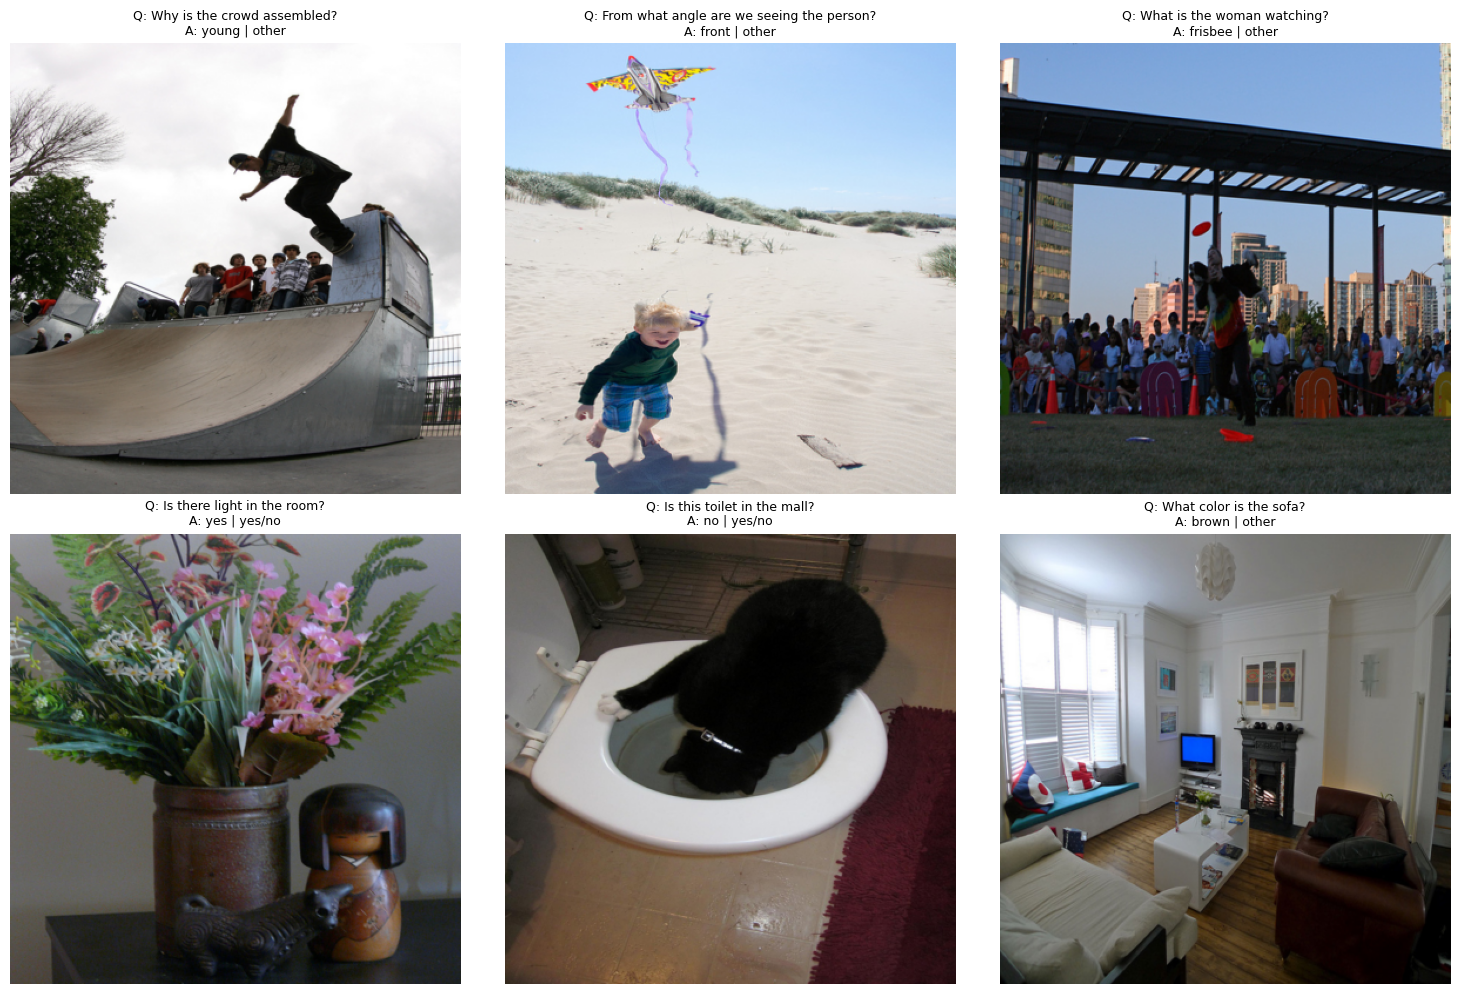

In [ ]:
# Visualize 6 samples (raw images only; skip when use_cache=True)
import matplotlib.pyplot as plt

if "image" not in batch:
    print("use_cache=True → no raw images in batch.\nRe-run with USE_CACHE=False to visualize.")
else:
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for i, ax in enumerate(axes.flat):
        img = (batch["image"][i] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(img)
        ax.set_title(
            f"Q: {batch['question'][i][:50]}\n"
            f"A: {batch['answer'][i]} | {batch['answer_type'][i]}",
            fontsize=9,
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
# Benchmark speed
import time

start = time.time()
for i, batch in enumerate(train_loader):
    if i >= 10: break
elapsed = time.time() - start

print(f"10 batches ({10*BATCH_SIZE} samples) in {elapsed:.2f}s")
print(f"→ ~{elapsed/10*1000:.0f}ms/batch | ~{10*BATCH_SIZE/elapsed:.0f} samples/sec")

NameError: name 'train_loader' is not defined

---
## 7. Export lên Drive

Lưu các file Python lên Drive để Sprint 3+ import:
- `src/vqa_dataset.py` — Dataset class + collate_fn + build_dataloader
- `src/pre_extract_features.py` — Script one-shot extract ViT features
- `data/ans2idx.json` — Answer vocabulary (3129 classes)


In [ ]:
import json, os

SRC_DIR = os.path.join(PROJECT_ROOT, "src")
os.makedirs(SRC_DIR, exist_ok=True)

# ── ans2idx.json ──────────────────────────────────────────────────────────────
vocab_path = os.path.join(PROJECT_ROOT, "data", "ans2idx.json")
with open(vocab_path, "w") as f:
    json.dump(ans2idx, f)
print(f"✅ {vocab_path}  ({len(ans2idx)} classes)")


# ── vqa_dataset.py ────────────────────────────────────────────────────────────
vqa_dataset_code = '''"""VQAv2 Dataset, collate_fn, build_dataloader — Sprint 2, Task 11+12
COCO 2014 filenames: COCO_train2014_000000XXXXXX.jpg
"""

import json
import os
import random
from collections import Counter
from typing import Dict, List, Optional

import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from transformers import AutoTokenizer


def build_answer_vocab(annotation_file: str, top_k: int = 3129) -> Dict[str, int]:
    """Count answer frequencies from train annotations; keep top_k → {answer: index}."""
    with open(annotation_file) as f:
        data = json.load(f)
    counter = Counter()
    for ann in data["annotations"]:
        for a in ann["answers"]:
            counter[a["answer"]] += 1
    return {ans: idx for idx, (ans, _) in enumerate(counter.most_common(top_k))}


class VQAv2Dataset(Dataset):
    """VQAv2 dataset supporting pre-extracted HDF5 cache and raw COCO 2014 images."""

    SPLIT_FILES = {
        "train": {
            "ann":        "v2_mscoco_train2014_annotations.json",
            "ques":       "v2_OpenEnded_mscoco_train2014_questions.json",
            "img_dir":    "train2014",
            "img_prefix": "COCO_train2014_",
            "cache":      "train_features.h5",
        },
        "val": {
            "ann":        "v2_mscoco_val2014_annotations.json",
            "ques":       "v2_OpenEnded_mscoco_val2014_questions.json",
            "img_dir":    "val2014",
            "img_prefix": "COCO_val2014_",
            "cache":      "val_features.h5",
        },
    }

    def __init__(self, split: str, config, use_cache: bool = True):
        assert split in ("train", "val")
        self.split, self.use_cache = split, use_cache
        cfg       = config.data
        data_root = cfg.data_root
        meta      = self.SPLIT_FILES[split]

        ann_path  = os.path.join(data_root, cfg.vqav2_dir, meta["ann"])
        ques_path = os.path.join(data_root, cfg.vqav2_dir, meta["ques"])
        self.image_dir  = os.path.join(data_root, cfg.coco_dir, meta["img_dir"])
        self.img_prefix = meta["img_prefix"]
        self._img_size  = getattr(cfg, "image_size", 224)

        with open(ann_path) as f:
            ann_data = json.load(f)
        with open(ques_path) as f:
            ques_data = json.load(f)

        qid2question = {q["question_id"]: q["question"] for q in ques_data["questions"]}
        self.samples: List[Dict] = []
        for ann in ann_data["annotations"]:
            qid      = ann["question_id"]
            question = qid2question.get(qid, "")
            if not question:
                continue
            raw_answers = [a["answer"] for a in ann["answers"]]
            self.samples.append({
                "question_id":  qid,
                "image_id":     ann["image_id"],
                "question":     question,
                "answers":      raw_answers,
                "answer":       ann.get("multiple_choice_answer",
                                        raw_answers[0] if raw_answers else ""),
                "answer_type":  ann.get("answer_type", "other"),
            })

        subset_size = cfg.train_size if split == "train" else cfg.val_size
        indices     = VQAv2Dataset._stratified_indices(self.samples, subset_size, cfg.seed)
        self.samples = [self.samples[i] for i in indices]

        self.transform = transforms.Compose([
            transforms.Resize((self._img_size, self._img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.48145466, 0.4578275, 0.40821073],
                std=[0.26862954, 0.26130258, 0.27577711],
            ),
        ])

        self._h5 = None
        if use_cache:
            self._h5_path = os.path.join(data_root, cfg.cache_dir, meta["cache"])
            if not os.path.exists(self._h5_path):
                raise FileNotFoundError(
                    f"Cache not found: {self._h5_path}\\n"
                    "Run pre_extract_features.py first, or use use_cache=False."
                )

        print(f"[VQAv2Dataset/{split}] {len(self.samples):,} samples | use_cache={use_cache}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        result = {
            "image_id":    s["image_id"],
            "question_id": s["question_id"],
            "question":    s["question"],
            "answers":     s["answers"],
            "answer":      s["answer"],
            "answer_type": s["answer_type"],
        }
        if self.use_cache:
            if self._h5 is None:
                self._h5 = h5py.File(self._h5_path, "r")
            result["image_features"] = torch.from_numpy(
                self._h5[str(s["image_id"])][()].astype("float32")
            )
        else:
            p = os.path.join(self.image_dir, f"{self.img_prefix}{s[\'image_id\']:012d}.jpg")
            if not os.path.exists(p):
                result["image"] = torch.zeros(3, self._img_size, self._img_size)
            else:
                result["image"] = self.transform(Image.open(p).convert("RGB"))
        return result

    @staticmethod
    def _stratified_indices(samples, subset_size, seed=42):
        rng = random.Random(seed)
        type2idx = {}
        for i, s in enumerate(samples):
            type2idx.setdefault(s["answer_type"], []).append(i)
        total, selected = len(samples), []
        for indices in type2idx.values():
            n = int(round(len(indices) / total * subset_size))
            rng.shuffle(indices)
            selected.extend(indices[:n])
        if len(selected) > subset_size:
            rng.shuffle(selected); selected = selected[:subset_size]
        elif len(selected) < subset_size:
            rem = list(set(range(total)) - set(selected))
            rng.shuffle(rem); selected.extend(rem[:subset_size - len(selected)])
        return selected


# ── Tokenizer ─────────────────────────────────────────────────────────────────
_tokenizer = None

def get_tokenizer(model_name="bert-base-uncased"):
    global _tokenizer
    if _tokenizer is None:
        _tokenizer = AutoTokenizer.from_pretrained(model_name)
    return _tokenizer


# ── collate_fn ────────────────────────────────────────────────────────────────
def collate_fn(batch):
    tokenizer = get_tokenizer()
    questions = [b["question"] for b in batch]
    enc = tokenizer(questions, padding=True, truncation=True, max_length=32, return_tensors="pt")
    result = {
        "question_ids":   enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "question":       questions,
        "question_id":    [b["question_id"]  for b in batch],
        "image_id":       [b["image_id"]     for b in batch],
        "answer":         [b["answer"]       for b in batch],
        "answers":        [b["answers"]      for b in batch],
        "answer_type":    [b["answer_type"]  for b in batch],
    }
    if "image_features" in batch[0]:
        result["image_features"] = torch.stack([b["image_features"] for b in batch])
    else:
        result["image"] = torch.stack([b["image"] for b in batch])
    return result


# ── build_dataloader ──────────────────────────────────────────────────────────
def build_dataloader(split, config, use_cache=True):
    """Build stratified DataLoader for train or val split."""
    ds = VQAv2Dataset(split, config, use_cache=use_cache)
    return DataLoader(
        ds,
        batch_size=config.data.batch_size,
        shuffle=(split == "train"),
        num_workers=4,
        collate_fn=collate_fn,
        pin_memory=True,
        drop_last=(split == "train"),
    )


if __name__ == "__main__":
    from omegaconf import OmegaConf
    cfg = OmegaConf.create({
        "data": {
            "data_root": "/content/data",
            "vqav2_dir": "vqav2", "coco_dir": "coco", "cache_dir": "cache",
            "train_size": 50000, "val_size": 10000,
            "image_size": 224, "seed": 42, "batch_size": 32,
        },
        "model": {"image_encoder": "openai/clip-vit-large-patch14", "query_dim": 768},
    })
    train_loader = build_dataloader("train", cfg, use_cache=False)
    batch = next(iter(train_loader))
    print("question_ids:", batch["question_ids"].shape)
    print("image:       ", batch["image"].shape)
'''

vqa_path = os.path.join(SRC_DIR, "vqa_dataset.py")
with open(vqa_path, "w") as f:
    f.write(vqa_dataset_code)
print(f"✅ {vqa_path}")


# ── pre_extract_features.py ───────────────────────────────────────────────────
pre_extract_code = '''"""Pre-extract ViT-L/14 (CLIP) image features for all COCO 2014 images.
Outputs: data/cache/train_features.h5 and val_features.h5
         Key: str(image_id), Value: float16 array (257, 1024)
Supports resume: skips image_ids already in the cache.
"""

import json
import os

import h5py
import torch
from PIL import Image
from tqdm import tqdm
from transformers import CLIPFeatureExtractor, CLIPVisionModel
from omegaconf import OmegaConf

from vqa_dataset import VQAv2Dataset


def pre_extract_features(
    config,
    split: str,
    device: str = "cuda",
    batch_size: int = 64,
) -> None:
    """Run ViT-L/14 on all COCO images for a split and save features to HDF5.

    Each image is saved as float16 with shape (257, 1024):
      - 1 CLS token + 256 patch tokens (ViT-L/14 @ 224)
      - dim = 1024

    Args:
        config:     OmegaConf config (data.* and model.image_encoder)
        split:      "train" or "val"
        device:     "cuda" or "cpu"
        batch_size: images per forward pass (reduce if OOM)
    """
    cfg       = config.data
    data_root = cfg.data_root
    meta      = VQAv2Dataset.SPLIT_FILES[split]

    img_dir    = os.path.join(data_root, cfg.coco_dir,    meta["img_dir"])
    ann_path   = os.path.join(data_root, cfg.vqav2_dir,   meta["ann"])
    cache_dir  = os.path.join(data_root, cfg.cache_dir)
    cache_path = os.path.join(cache_dir, meta["cache"])
    os.makedirs(cache_dir, exist_ok=True)

    # All unique image_ids referenced in VQAv2 annotations
    with open(ann_path) as f:
        ann_data = json.load(f)
    image_ids = sorted({ann["image_id"] for ann in ann_data["annotations"]})
    print(f"[pre_extract/{split}] {len(image_ids):,} unique images → {cache_path}")

    # Load CLIP vision model
    model_name = config.model.image_encoder
    print(f"Loading {model_name} ...")
    processor  = CLIPFeatureExtractor.from_pretrained(model_name)
    model      = CLIPVisionModel.from_pretrained(model_name).to(device).eval()
    print(f"Model loaded on {device} ✅")

    with h5py.File(cache_path, "a") as h5f:
        existing   = set(h5f.keys())
        to_process = [iid for iid in image_ids if str(iid) not in existing]
        print(f"  Already cached: {len(existing):,} | Remaining: {len(to_process):,}")

        for i in tqdm(range(0, len(to_process), batch_size), desc=f"Extracting {split}"):
            ids    = to_process[i : i + batch_size]
            imgs, valid_ids = [], []

            for iid in ids:
                p = os.path.join(img_dir, f"{meta[\'img_prefix\']}{iid:012d}.jpg")
                if not os.path.exists(p):
                    continue
                try:
                    imgs.append(Image.open(p).convert("RGB"))
                    valid_ids.append(iid)
                except Exception:
                    continue

            if not imgs:
                continue

            inputs = processor(images=imgs, return_tensors="pt").to(device)
            with torch.no_grad():
                feats = model(**inputs).last_hidden_state  # (B, 257, 1024)
                feats = feats.cpu().numpy().astype("float16")

            for j, iid in enumerate(valid_ids):
                h5f.create_dataset(
                    str(iid), data=feats[j],
                    compression="gzip", compression_opts=1,
                )

    print(f"✅ Done! Cache: {cache_path}")


if __name__ == "__main__":
    cfg = OmegaConf.create({
        "data": {
            "data_root": "/content/data",
            "vqav2_dir": "vqav2", "coco_dir": "coco", "cache_dir": "cache",
            "train_size": 50000, "val_size": 10000,
            "image_size": 224, "seed": 42, "batch_size": 32,
        },
        "model": {"image_encoder": "openai/clip-vit-large-patch14", "query_dim": 768},
    })
    for s in ["train", "val"]:
        pre_extract_features(cfg, s, device="cuda", batch_size=64)
'''

pre_extract_path = os.path.join(SRC_DIR, "pre_extract_features.py")
with open(pre_extract_path, "w") as f:
    f.write(pre_extract_code)
print(f"✅ {pre_extract_path}")

print("\n📂 Drive structure:")
print(f"   {PROJECT_ROOT}/")
print(f"   ├── data/")
print(f"   │   ├── ans2idx.json")
print(f"   │   ├── cache/")
print(f"   │   │   ├── train_features.h5  ← after pre-extract")
print(f"   │   │   └── val_features.h5")
print(f"   │   ├── vqav2/  (Task 9)")
print(f"   │   └── coco/   (Task 10 — train2014/ val2014/)")
print(f"   └── src/")
print(f"       ├── vqa_dataset.py")
print(f"       └── pre_extract_features.py")


In [ ]:
# Test import from exported files
import sys
sys.path.insert(0, SRC_DIR)

from vqa_dataset import (
    build_answer_vocab  as _bav,
    VQAv2Dataset        as _VDS,
    collate_fn          as _cfn,
    build_dataloader    as _bdl,
)
from pre_extract_features import pre_extract_features as _pef

print("✅ Import thành công — Sprint 3+ dùng được ngay:")
print()
print("    import sys")
print(f"    sys.path.insert(0, '{SRC_DIR}')")
print("    from vqa_dataset import build_dataloader")
print(f"    train_loader = build_dataloader('train', cfg, use_cache=True)")
print()
print("    # One-time pre-extraction (chạy 1 lần duy nhất):")
print("    from pre_extract_features import pre_extract_features")
print("    pre_extract_features(cfg, 'train', device='cuda')")


In [ ]:
print("🎉 Task 11+12 DONE")
print()
print("📋 Sprint 2 checklist:")
print("   Task  9: Download VQAv2              ✅")
print("   Task 10: Download COCO 2014          ✅")
print("   Task 11: VQAv2Dataset class          ✅  (use_cache + COCO 2014 fmt)")
print("   Task 12: build_dataloader + collate  ✅  (BERT tokenizer)")
print()
print("🔜 Trước khi train (Task 13+):")
print("   1. Chạy pre_extract_features(cfg, 'train')  → train_features.h5  (~43 GB float16)")
print("   2. Chạy pre_extract_features(cfg, 'val')    → val_features.h5")
print("   3. Đổi USE_CACHE = True → build_dataloader sẽ đọc từ cache")
